Thinking...
Thinking...


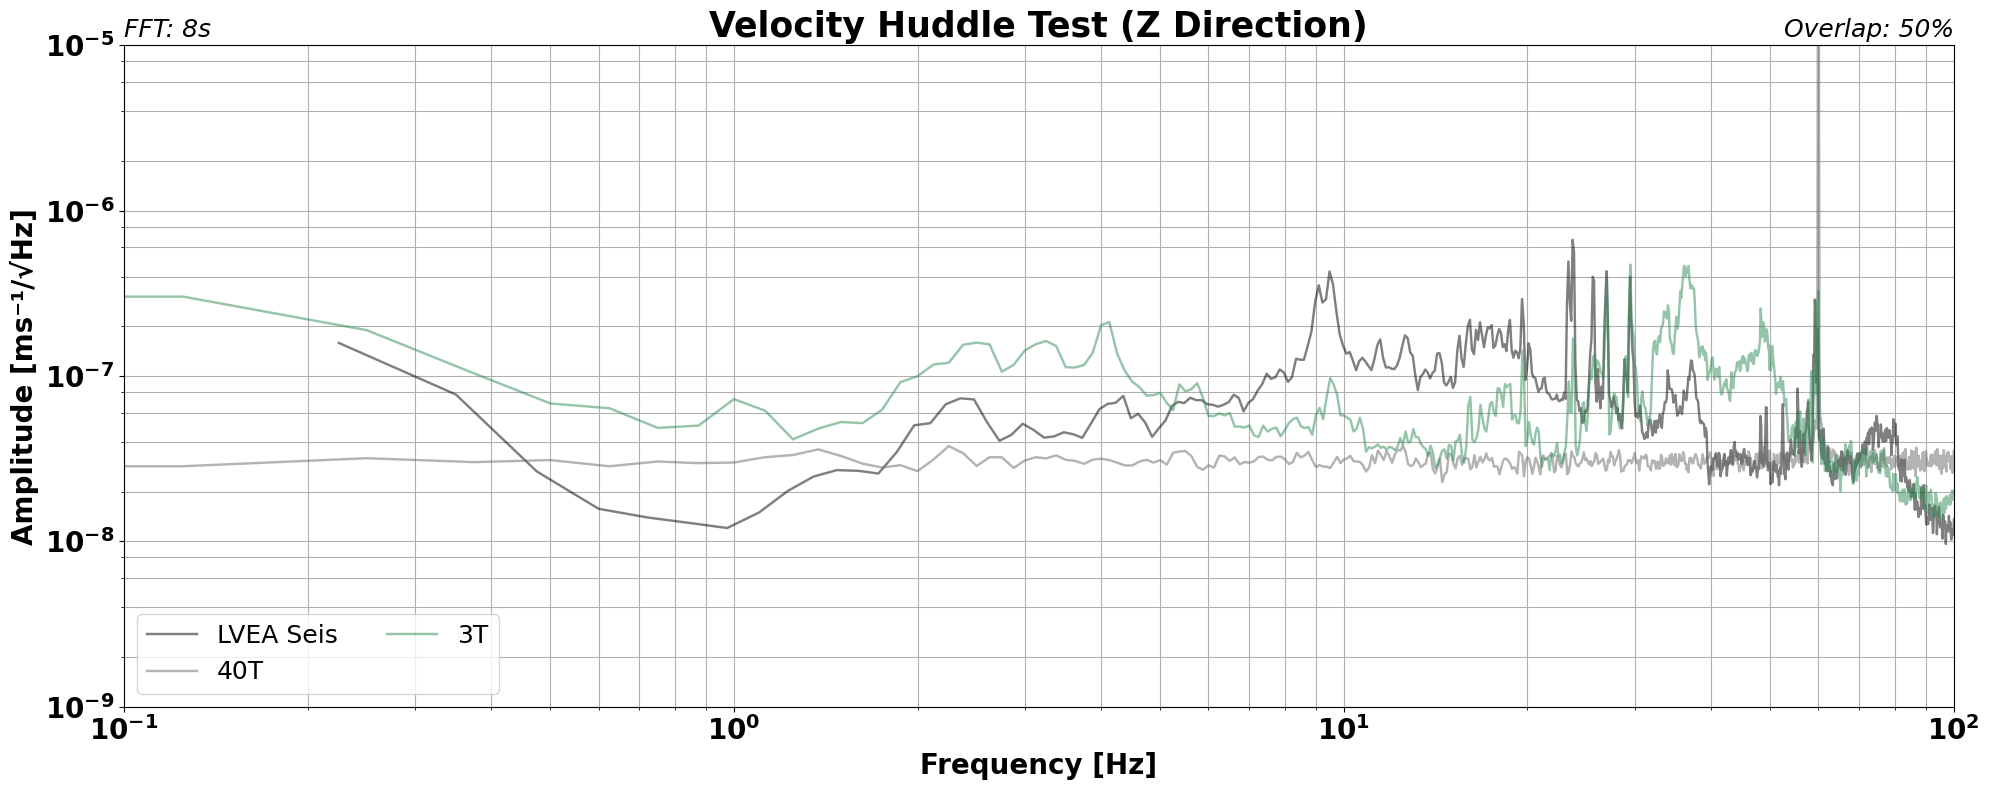

In [56]:
print("Thinking...")
import warnings
import pandas as pd                    # For reading CSV files into tables
import numpy as np                     # For numerical calculations
print("Thinking...")
from scipy import signal               # For the Welch PSD / spectral analysis
from matplotlib import pyplot as plt   # For creating plots
import matplotlib.ticker as ticker
import os

warnings.simplefilter('ignore')

###--------------------------------------------------------------------------------------------------------------------------###
'''------------------------------------------------- SECTION 1 — FILE PATH --------------------------------------------------'''
###--------------------------------------------------------------------------------------------------------------------------###


field = (r"C:\Users\cacam\Downloads\seis_2026-07-07_1046-1051.csv")


ligo = (r"C:\Users\cacam\Downloads\h46.txt")



###--------------------------------------------------------------------------------------------------------------------------###



## ---------------------------------------------------- ##

Forty_T_First = True                                         # Set to True if pre-amps were active

## ---------------------------------------------------- ##

## ---------------------------------------------------- ##

#function = "Displacement"

function = "velo"

## ---------------------------------------------------- ##



###--------------------------------------------------------------------------------------------------------------------------###
'''------------------------------------------ SECTION 2 — READ THE FIELD DATA FILE ------------------------------------------'''
###--------------------------------------------------------------------------------------------------------------------------###



metadata_rows = []
metadata = {}


with open(field, 'r') as f:
    for _ in range(5):
        metadata_rows.append(f.readline().strip())

for row in metadata_rows:
    if ':' in row:
        key, value = row.split(':', 1)
        metadata[key.strip()] = value.strip()

kit_sr = float(metadata["Sample Rate"])

seis = pd.read_csv(field, skiprows = 5, delimiter = ',')


if Forty_T_First == True:
    seis.columns = ["Sample", "Time (s)", 
                        "40T N", "40T Z", 
                        "3T N", "3T Z", 
                        "blank"]
else:
    seis.columns = ["Sample", "Time (s)", 
                        "3T N", "3T Z", 
                        "40T N", "40T Z", 
                        "blank"]

    
calibration = 0.0125e-1
    
forty_t_n   = seis["40T N"] * calibration 
forty_t_z   = seis["40T Z"] * calibration

three_t_n   = seis["3T N"]  * calibration 
three_t_z   = seis["3T Z"]  * calibration 



## ------------------------------------------------------ LVEA Data --------------------------------------------------------- ##

lvea = pd.read_csv(ligo, delimiter = '\s+')
lvea.columns = ["freq", "velo"]

lvea_freq = lvea["freq"] 
lvea_velo = lvea["velo"] * 0.0076e-6

###--------------------------------------------------------------------------------------------------------------------------###





###--------------------------------------------------------------------------------------------------------------------------###
'''----------------------------------------------- SECTION 3 — PLOT SETTINGS ------------------------------------------------'''
###--------------------------------------------------------------------------------------------------------------------------###



## Adjust these to control how the output plots look and how the FFT is computed.


# Y-axis (amplitude) range in m/√Hz or m·s⁻¹/√Hz:
y_max      = 10e-6                                         # Top of the plot    (higher = more noise visible)
y_min      = 10e-10                                        # Bottom of the plot (lower = more detail at quiet levels)


# X-axis (frequency) range in Hz:
x_max      = 100                                           # Highest frequency to show
x_min      = 0.1                                           # Lowest frequency to show


# FFT (spectral analysis) settings:
fft_length = 8                                             # Length of each FFT window in seconds
                                                           #   Longer = better frequency resolution, less time averaging

overlap    = 50                                            # Overlap between consecutive FFT windows, in percent (0–99)


## ---------------------------------------------------- ##

plot_title = "Velocity Huddle Test (Z Direction)"
plot_ylabel = "Amplitude [ms⁻¹/√Hz]"

    
## ---------------------------------------------------- ##



###--------------------------------------------------------------------------------------------------------------------------###
'''------------------------------------ SECTION 4 — ASD CALCULATION AND PLOTTING FUNCTION -----------------------------------'''
###--------------------------------------------------------------------------------------------------------------------------###

    
    
## ---------------------------------------------------- ##

def welch_asd(data, sr):
    data = np.asarray(data)
    
    
    frequencies, power = signal.welch(
        
        data, 
        sr, 
        window    = 'hamming',
        nperseg   = int(sr * fft_length),
        noverlap  = int(round(sr * (overlap * 0.01)) ) 
    )
    
   
    return frequencies, power

## ---------------------------------------------------- ##

freq1, amp1 = welch_asd(forty_t_z, kit_sr)
freq2, amp2 = welch_asd(three_t_z, kit_sr)


y_axis_1 = np.sqrt(amp1)
y_axis_2 = np.sqrt(amp2)

## ---------------------------------------------------- ##



###--------------------------------------------------------------------------------------------------------------------------###
'''------------------------------------------------- SECTION 5 — PLot Data --------------------------------------------------'''
###--------------------------------------------------------------------------------------------------------------------------###



plt.figure(figsize=(20, 8))  # one figure for all files


plt.plot(lvea_freq, lvea_velo,
         color      = "black",
         linewidth  = 1.75,
         alpha      = 0.5,
         label      = "LVEA Seis")

plt.plot(freq1, y_axis_1,
         color      = "dimgrey",
         linewidth  = 1.75,
         alpha      = 0.5,
         label      = "40T")
plt.plot(freq2, y_axis_2,
         color      = "seagreen",
         linewidth  = 1.75,
         alpha      = 0.5,
         label      = "3T")



plt.yscale('log')
plt.xscale('log')

ax = plt.gca()
ax.minorticks_on()

plt.title(plot_title, fontweight = 'bold', fontsize = 25)
plt.title(f'FFT: {fft_length}s', fontsize = 18, loc = 'left', style = 'italic')
plt.title(f'Overlap: {overlap}%', fontsize = 18, loc = 'right', style = 'italic')

plt.xlabel('Frequency [Hz]', fontweight = 'bold', fontsize = 20)
plt.ylabel(plot_ylabel, fontweight = 'bold', fontsize = 20)

plt.yticks(fontsize = 20, fontweight = 'bold')
plt.xticks(fontsize = 20, fontweight = 'bold')


ax.tick_params(axis = 'both', which = 'minor', labelsize = 16)
for label in ax.get_yticklabels(which = 'minor'):
    label.set_fontweight('bold')
    
for label in ax.get_xticklabels(which = 'minor'):
    label.set_fontweight('bold')

    
ax.yaxis.set_major_locator(ticker.LogLocator(base     = 10.0, 
                                             numticks = 20))

ax.yaxis.set_minor_locator(ticker.LogLocator(base     = 10.0, 
                                             subs     = (0.2, 0.4, 0.6, 0.8), 
                                             numticks = 20))

plt.ylim(y_min, y_max)
plt.xlim(x_min, x_max)

plt.legend(loc = 'lower left', fontsize = 18, ncol = 2)
plt.grid(True, which = 'both', ls = '-')
plt.tight_layout()
plt.savefig("huddle_46-51.png")
plt.show()